<a href="https://colab.research.google.com/github/oleg61/DataScient/blob/Learn_AI/%D0%94%D0%971_%D0%92%D0%BE%D1%80%D0%BE%D0%BF%D0%B0%D0%B5%D0%B2_%D0%9E%D0%A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
import statsmodels.tsa.api as smt
import matplotlib.pyplot as plt
from scipy.stats import boxcox
%matplotlib inline

In [ ]:
def test_stationarity(timeseries, title=""):
    print(f"\n{'='*50}")
    if title:
        print(f"Ряд: {title}")
    print("Результаты теста Дики-Фуллера:")
    dftest = adfuller(timeseries.dropna(), autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for key, value in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value
    print(dfoutput)
    return dfoutput

In [ ]:
def tsplot(series, title):
    series = series.dropna()
    res = adfuller(series, autolag='AIC')
    print(f"\n--- {title} ---")
    print(f"Test Statistic: {res[0]:.4f}")
    print(f"Critical Value (1%): {res[4]['1%']:.4f}")
    print("✅ Стационарен" if res[0] < res[4]['1%'] else "❌ Не стационарен")

    plt.figure(figsize=(10, 3))
    plt.plot(series, color='steelblue')
    plt.title(title)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Путь размещения датасетов
DATA_PATH = '/content/drive/MyDrive/0. DataScients (Netology)/Временные ряды/1/'

In [ ]:
female_births = pd.read_csv(DATA_PATH + 'daily-total-female-births-in-cal.csv')['Count']
airlines_passengers = pd.read_csv(DATA_PATH + 'international-airline-passengers.csv')['Count']
mean_monthly_temp = pd.read_csv(DATA_PATH + 'mean-monthly-air-temperature-deg.csv')['Deg']
robberies_in_boston = pd.read_csv(DATA_PATH + 'monthly-boston-armed-robberies-j.csv')['Count']
sales_of_company_x = pd.read_csv(DATA_PATH + 'monthly-sales-of-company-x-jan-6.csv')['Count']
dowjones_closing = pd.read_csv(DATA_PATH + 'weekly-closings-of-the-dowjones-.csv')['Close']

print("✅ Данные загружены")

✅ Данные загружены


In [ ]:
data = {
    "sales": pd.read_csv(DATA_PATH + 'monthly-sales-of-company-x-jan-6.csv')["Count"],
    "robberies": pd.read_csv(DATA_PATH + 'monthly-boston-armed-robberies-j.csv')["Count"],
    "airline": pd.read_csv(DATA_PATH + 'international-airline-passengers.csv')["Count"],
    "temp": pd.read_csv(DATA_PATH + 'mean-monthly-air-temperature-deg.csv')["Deg"],
    "dowjones": pd.read_csv(DATA_PATH + 'weekly-closings-of-the-dowjones-.csv')["Close"],
    "births": pd.read_csv(DATA_PATH + 'daily-total-female-births-in-cal.csv')["Count"]
}

# 1. Monthly sales of company X


--- Sales — оригинал ---
Test Statistic: 0.6547
Critical Value (1%): -3.5369
❌ Не стационарен


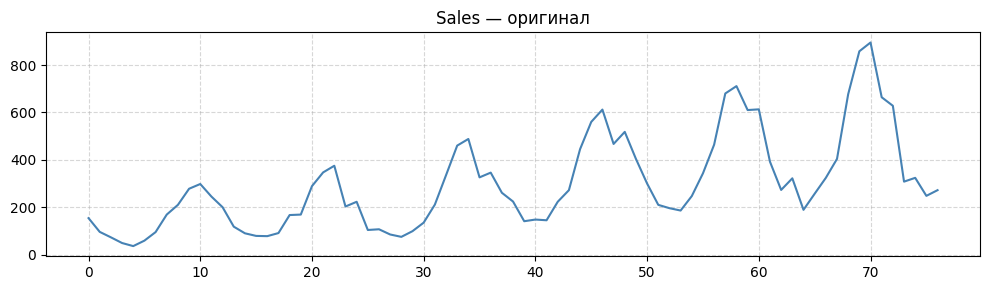


--- Sales — Box-Cox ---
Test Statistic: -0.6313
Critical Value (1%): -3.5369
❌ Не стационарен


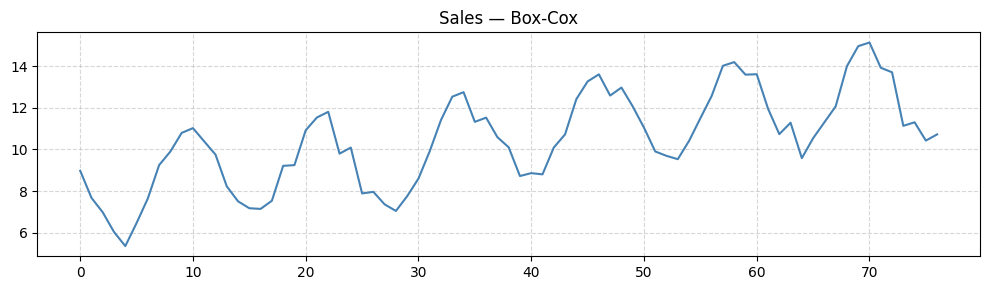


--- Sales — сезонность ---
Test Statistic: -2.3405
Critical Value (1%): -3.5602
❌ Не стационарен


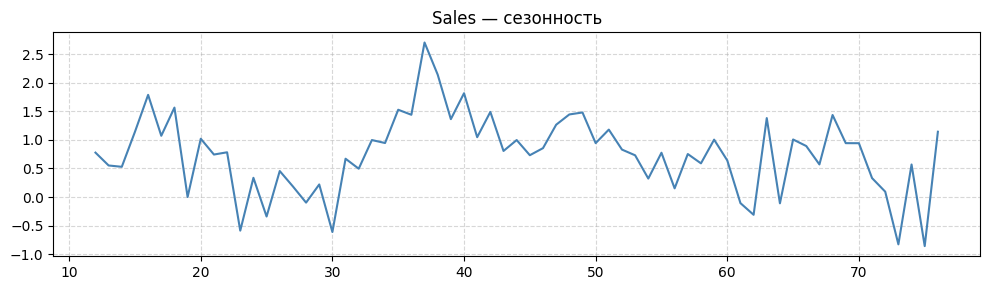


--- Sales —  дифференцирование ---
Test Statistic: -2.3513
Critical Value (1%): -3.5602
❌ Не стационарен


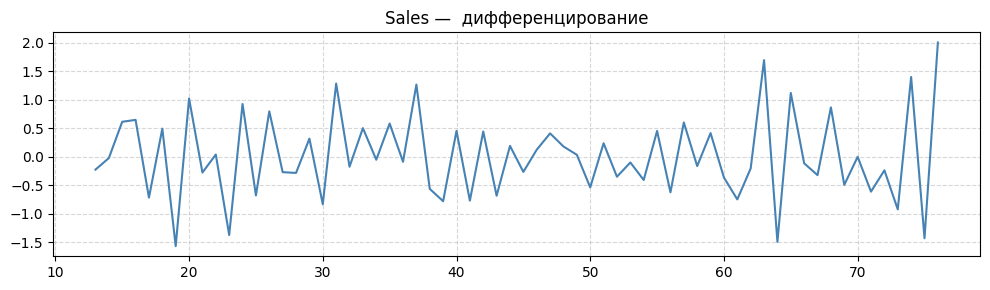


--- Sales - Повторим дифферинцирование ---
Test Statistic: -5.4859
Critical Value (1%): -3.5602
✅ Стационарен


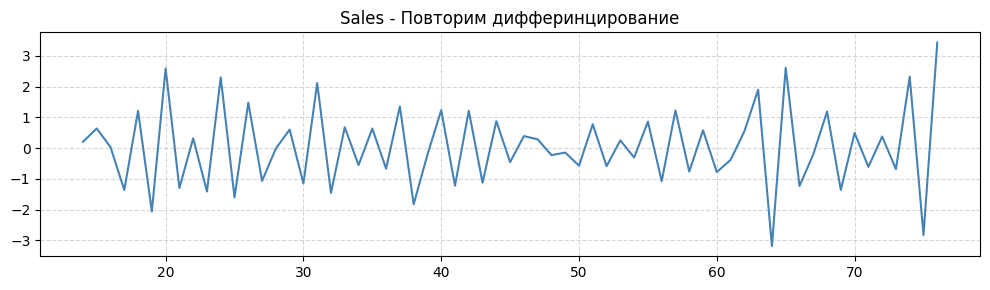

In [ ]:
ts = data["sales"]
tsplot(ts, "Sales — оригинал")
ts = pd.Series(boxcox(ts)[0])
tsplot(ts, "Sales — Box-Cox")
ts = ts.diff(12)
tsplot(ts, "Sales — сезонность")
ts = ts.diff()
tsplot(ts, "Sales —  дифференцирование")
ts = ts.diff()
tsplot(ts, "Sales - Повторим дифферинцирование")

# 2. Boston robberies


--- Robberies — оригинал ---
Test Statistic: 1.0011
Critical Value (1%): -3.4936
❌ Не стационарен


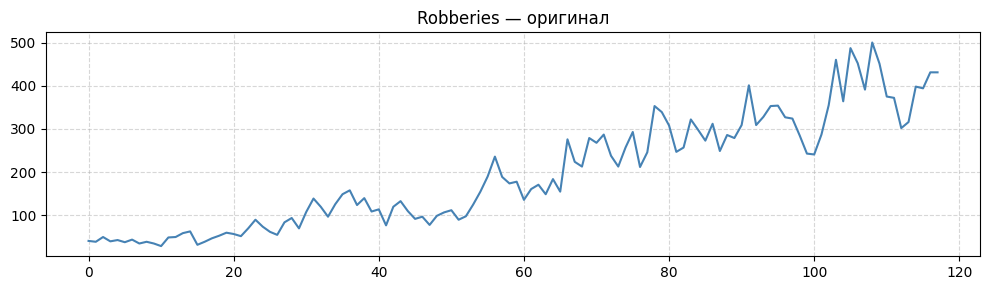


--- Robberies — Box-Cox ---
Test Statistic: -0.8763
Critical Value (1%): -3.4936
❌ Не стационарен


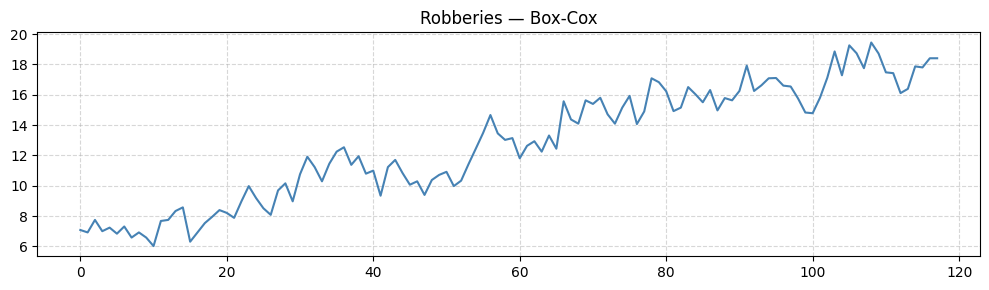


--- Robberies — сезоннсть ---
Test Statistic: -2.7419
Critical Value (1%): -3.5027
❌ Не стационарен


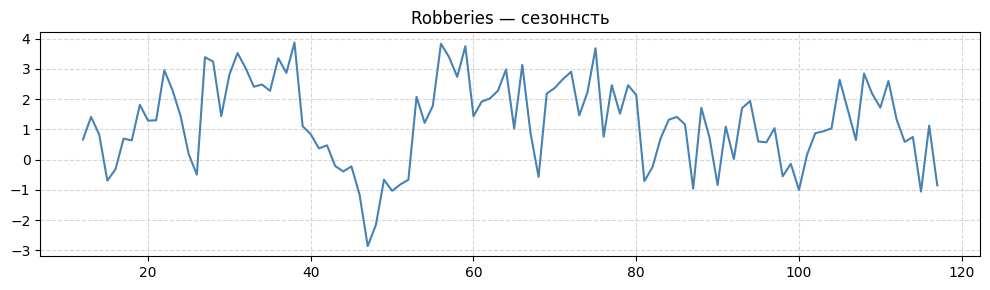


--- Robberies — дифференцирование ---
Test Statistic: -4.2650
Critical Value (1%): -3.5035
✅ Стационарен


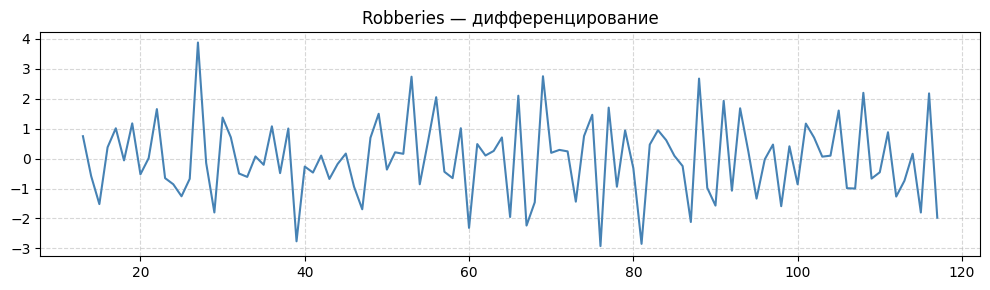

In [ ]:
ts = data["robberies"]
tsplot(ts, "Robberies — оригинал")
ts = pd.Series(boxcox(ts)[0])
tsplot(ts, "Robberies — Box-Cox")
ts = ts.diff(12)
tsplot(ts, "Robberies — сезоннсть")
ts = ts.diff()
tsplot(ts, "Robberies — дифференцирование")

# 3. Airline passengers


--- Airline — оригинал ---
Test Statistic: 0.8154
Critical Value (1%): -3.4817
❌ Не стационарен


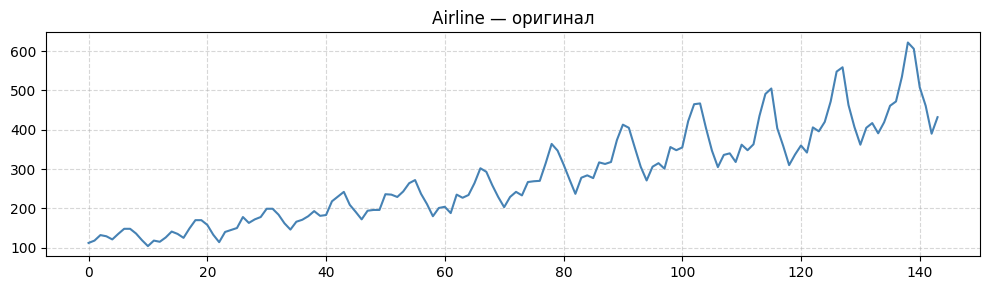


--- Airline — log ---
Test Statistic: -1.7170
Critical Value (1%): -3.4817
❌ Не стационарен


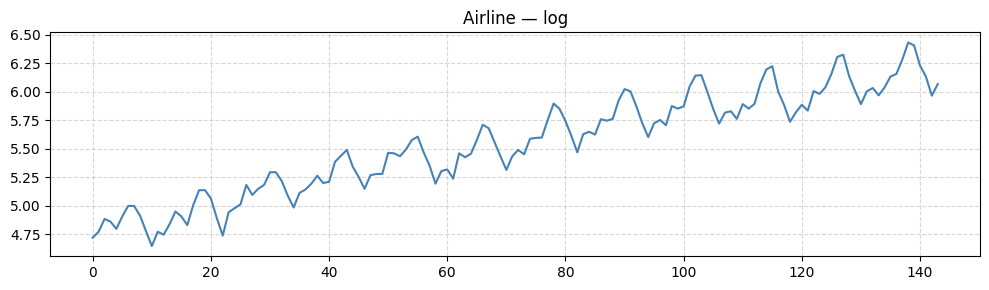


--- Airline — сезоннсть ---
Test Statistic: -2.7096
Critical Value (1%): -3.4865
❌ Не стационарен


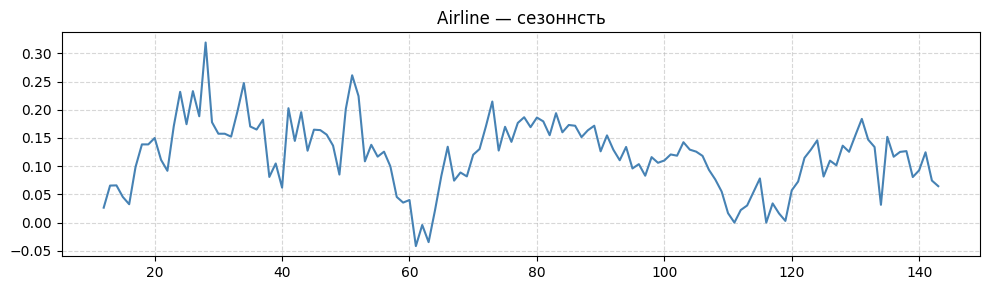


--- Airline — дифференцирование ---
Test Statistic: -4.4433
Critical Value (1%): -3.4870
✅ Стационарен


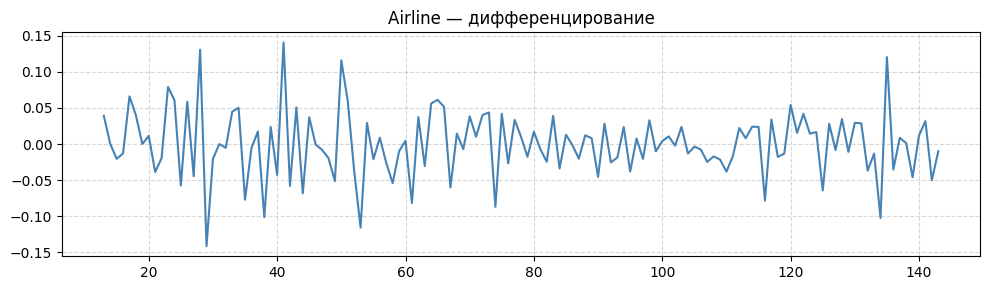

In [ ]:
ts = data["airline"]
tsplot(ts, "Airline — оригинал")
ts = np.log(ts)
tsplot(ts, "Airline — log")
ts = pd.Series(ts).diff(12)
tsplot(ts, "Airline — сезоннсть")
ts = pd.Series(ts).diff()
tsplot(ts, "Airline — дифференцирование")

# 4. Monthly temperature


--- Temp — оригинал ---
Test Statistic: -3.2555
Critical Value (1%): -3.4598
❌ Не стационарен


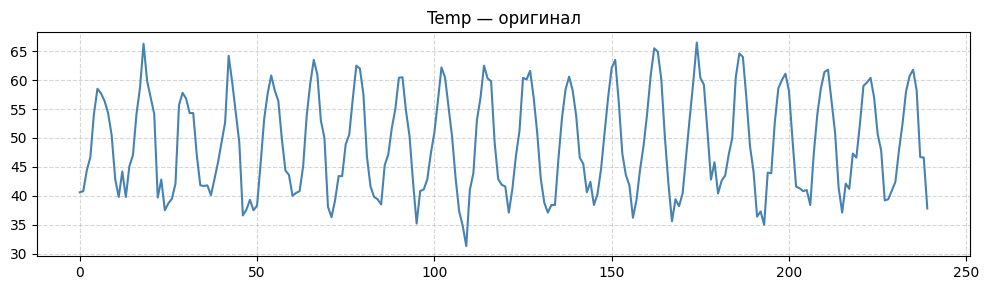


--- Temp — сезонность ---
Test Statistic: -6.0725
Critical Value (1%): -3.4611
✅ Стационарен


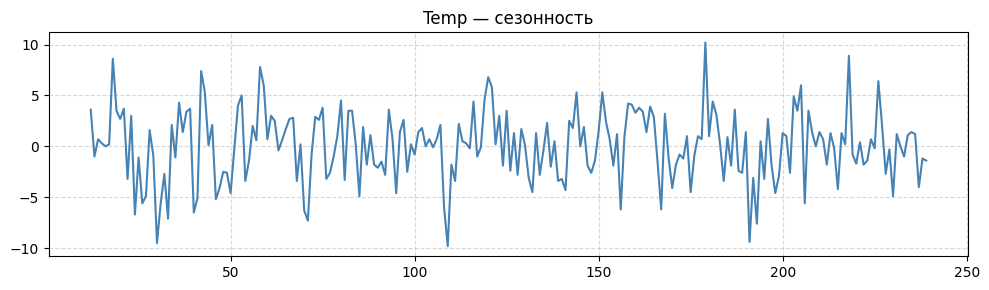

In [ ]:
ts = data["temp"]
tsplot(ts, "Temp — оригинал")
ts = pd.Series(ts).diff(12)
tsplot(ts, "Temp — сезонность")
#не понадобилось
#ts = pd.Series(ts).diff()
#tsplot(ts, "Temp - дифференцирование")

# 5. Dow Jones


--- DowJones — оригинал ---
Test Statistic: -1.3146
Critical Value (1%): -3.4716
❌ Не стационарен


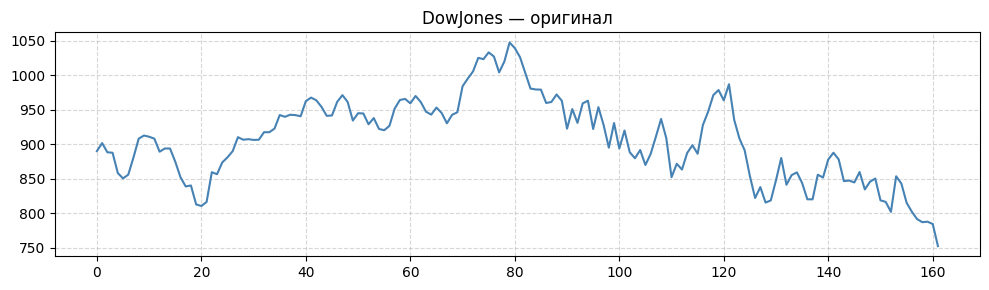


--- DowJones — log ---
Test Statistic: -1.2104
Critical Value (1%): -3.4716
❌ Не стационарен


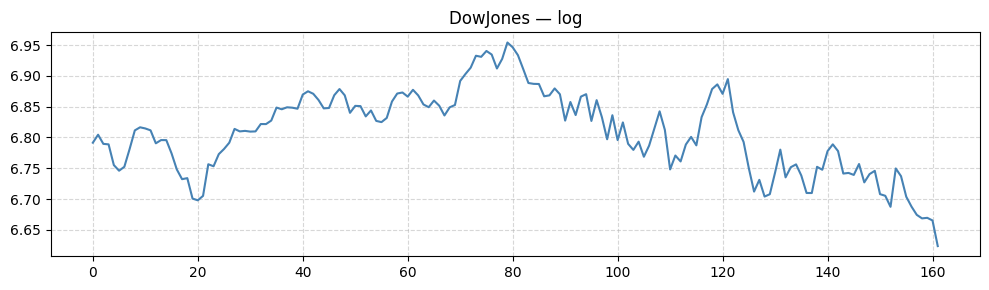


--- DowJones — сезоннсоть ---
Test Statistic: -1.1482
Critical Value (1%): -3.4918
❌ Не стационарен


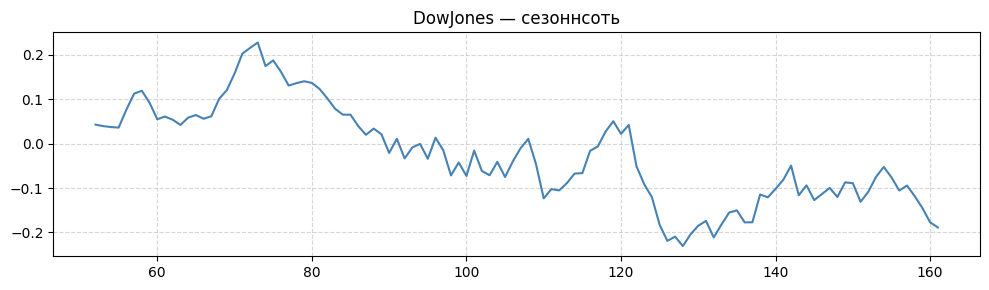


--- DowJones - дифференцирование ---
Test Statistic: -4.9337
Critical Value (1%): -3.4955
✅ Стационарен


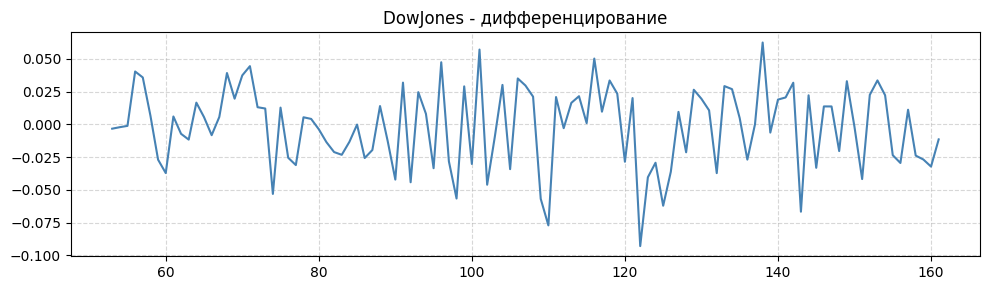

In [ ]:
ts = data["dowjones"]
tsplot(ts, "DowJones — оригинал")
ts = np.log(ts)
tsplot(ts, "DowJones — log")
ts = pd.Series(ts).diff(52)
tsplot(ts, "DowJones — сезоннсоть")
ts = pd.Series(ts).diff()
tsplot(ts, "DowJones - дифференцирование")

# 6. Female births


--- Births — оригинал ---
Test Statistic: -4.8083
Critical Value (1%): -3.4487
✅ Стационарен


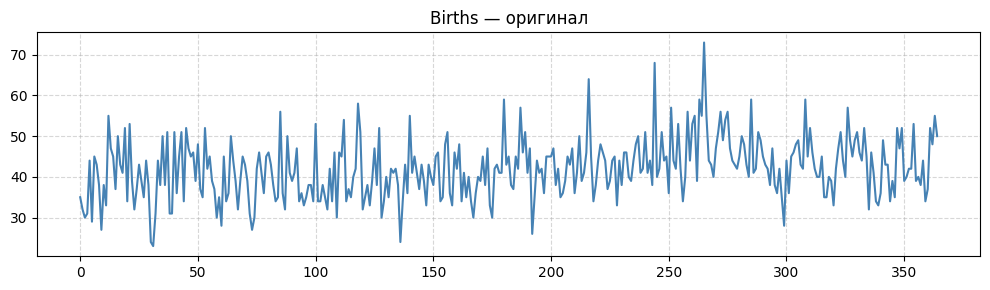

In [ ]:
ts = data["births"]
tsplot(ts, "Births — оригинал")
#Далее не продолжаем, ряд стационарен
#ts = pd.Series(ts).diff()
#tsplot(ts, "Births — дифференцирование")
#ts = ts.diff(7)
#tsplot(ts, "Births — сезонность")